### plan node 점검 

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *

start_langsmith("final_music")
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music


In [12]:
class State(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    next_agent: Annotated[str, " use agent"]

In [13]:
past_template = """ 
    # System :
    You are an AI assistant
    If you need music information, search Genie Music and get information

    I want you to judge yourself to bring information without asking the user for additional information, bring information, and recommend it.

    # History : 
    {messages}

    # Impotant : 
    Answer in Korean
    """
past_prompt = ChatPromptTemplate.from_template(past_template)

In [14]:
replanner_prompt = ChatPromptTemplate.from_template(
    """You can modify your current plan to achieve your given goals.
        Too many planning modifications make it harder to achieve your goals.
        So, it may be more effective to modify your goals or do the remaining plans. Don't skip the steps.

        Your objective was this:
        {input}

        Your original plan was this:
        {plan}

        You have currently done the follow steps:
        {past_steps}

        # Important
        Do not return the steps taken previously as part of your plan.
        If you have any remaining plans, please remove the one you are currently running.
        MusicResponse If No More Plans Left, If Plans Exist, Deliver PlanListModel Plans
        
        Answer in Korean.
        """
)

In [15]:
def plan_node(state: State) -> State:
    llm = get_gemini()
    prompt = get_prompt_music_planner()
    chain = prompt | llm.with_structured_output(PlanListModel)
    response = chain.invoke({"messages": [state["question"]]})
    return State({"plan": response.steps, "messages": response.steps})


def past_steps(state: State):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {text}" for i, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {plan_str} \n\n You are tasked with executing [step 1. {task}]."""
    llm = past_prompt | get_gemini()
    result = llm.invoke({"messages": task_str})
    latest_messages = f" Question :{task}\n Response :{result.content}"
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})


def replan_node(state: State):
    prompt = replanner_prompt
    llm = get_gpt().with_structured_output(MusicAct)
    chain = prompt | llm
    response = chain.invoke(
        {
            "input": state["question"],
            "plan": state["plan"],
            "past_steps": state["past_steps"][-1].content,
        }
    )
    if isinstance(response.action, MusicResponse):
        return State({"answer": response.action.response})
    else:  # result == Plan
        next_plan = response.action.steps
        if len(next_plan) == 0:
            return {"answer": "No more steps needed."}
        else:
            return {"plan": next_plan}

In [16]:
state_graph = StateGraph(State)
state_graph.add_node("plan_node", plan_node)
state_graph.add_node("past_steps", past_steps)
state_graph.add_node("replan_node", replan_node)

state_graph.add_edge(START, "plan_node")
state_graph.add_edge("plan_node", "past_steps")
state_graph.add_edge("past_steps", "replan_node")
state_graph.add_edge("replan_node", END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

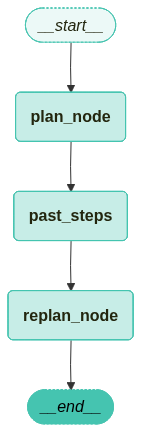

In [17]:
visualize_graph(graph)

In [18]:
request_template = """ 
    # System :
    You are an AI assistant
    Genie Music users, please create different types of queries
    I'm gonna get you to judge the performance of the llm agent

    # History : 
    {messages}

    # Answer : 
    Please write your answers in an array of short answers
    ['a','b','c'...]

    # Impotant : 
    Answer in Korean
    """
request_prompt = ChatPromptTemplate.from_template(request_template)

In [19]:
# llm = request_prompt | get_gemini() | StrOutputParser()
# queries = llm.invoke("질문 생성해줘")
# print(queries)
# import ast

# result = ast.literal_eval(queries)
result = [
    "오늘의 인기곡 알려줘",
    "최신 발매된 K-POP 신곡 추천해줘",
    "잔잔한 발라드 플레이리스트 만들어줘",
    "신나는 댄스곡 모음 틀어줘",
    "운동할 때 듣기 좋은 노래 추천해줘",
    "집중력을 높여주는 음악 틀어줘",
    "잠들기 전에 듣기 좋은 ASMR 추천해줘",
    "내가 좋아하는 가수 A의 신곡 나왔는지 알려줘",
    "이 노래 제목이 뭐야?",
    "이 노래 누가 불렀어?",
    "이 노래 가사 보여줘",
    "이 노래랑 비슷한 분위기의 노래 추천해줘",
    "이 노래를 플레이리스트에 추가해줘",
    "이 플레이리스트 이름 바꿔줘",
    "이 플레이리스트 삭제해줘",
    "내가 최근에 들은 노래 목록 보여줘",
    "내가 가장 많이 들은 노래 알려줘",
    "이 노래를 친구에게 공유해줘",
    "음악 검색 기록 삭제해줘",
    "오늘 날씨에 어울리는 노래 추천해줘",
]

In [20]:
for idx, query in enumerate(result):
    inputs = {"question": query, "messages": query}
    config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())
    response = graph.invoke(input=inputs, config=config, stream_mode="values")
    print(response)
    if idx == 3:
        break

{'question': '오늘의 인기곡 알려줘', 'plan': ['가져온 20곡이 서비스에 있는지 확인합니다.', '최종 곡 리스트를 선택하여 추가합니다.'], 'messages': [HumanMessage(content='오늘의 인기곡 알려줘', additional_kwargs={}, response_metadata={}, id='216970f6-1907-4751-b03e-7472e3294052'), HumanMessage(content='오늘의 인기곡 20곡을 가져옵니다.', additional_kwargs={}, response_metadata={}, id='2796bf70-1f33-4646-89bc-4d0819949bee'), HumanMessage(content='가져온 곡이 서비스에 있는지 확인합니다.', additional_kwargs={}, response_metadata={}, id='89627ea2-e25e-4adb-a55a-ad86e2238fab'), HumanMessage(content='최종 곡 리스트를 선택하여 추가합니다.', additional_kwargs={}, response_metadata={}, id='3cf66803-3e9b-4cea-9a55-1be2720985ae'), HumanMessage(content=' Question :오늘의 인기곡 20곡을 가져옵니다.\n Response :## 오늘의 인기곡 20곡 가져오기\n\nGenie Music에서 오늘의 인기곡 20곡을 가져왔습니다.\n\n1. **NewJeans - Hype Boy**\n2. **IVE - LOVE DIVE**\n3. **(G)I-DLE - TOMBOY**\n4. **LE SSERAFIM - FEARLESS**\n5. **BLACKPINK - Pink Venom**\n6. **BTS - Dynamite**\n7. **aespa - Next Level**\n8. **ITZY - WANNABE**\n9. **TWICE - The Feels**\n10. **